In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [14]:
df = pd.read_json('/kaggle/input/datasets/weiweip/ember2024/Win64_train/2023-09-24_2023-09-30_Win64_train.jsonl', lines=True)
print(df.shape)

(20000, 32)


In [3]:
df.info()
# nested columns for human readable format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   md5                    20000 non-null  object 
 1   sha1                   20000 non-null  object 
 2   sha256                 20000 non-null  object 
 3   tlsh                   20000 non-null  object 
 4   first_submission_date  20000 non-null  int64  
 5   last_analysis_date     20000 non-null  int64  
 6   detection_ratio        20000 non-null  object 
 7   label                  20000 non-null  int64  
 8   file_type              20000 non-null  object 
 9   family                 8188 non-null   object 
 10  family_confidence      8188 non-null   float64
 11  behavior               20000 non-null  object 
 12  file_property          20000 non-null  object 
 13  packer                 20000 non-null  object 
 14  exploit                20000 non-null  object 
 15  gr

<Axes: title={'center': 'Malware (1) vs Benign (0)'}, xlabel='label'>

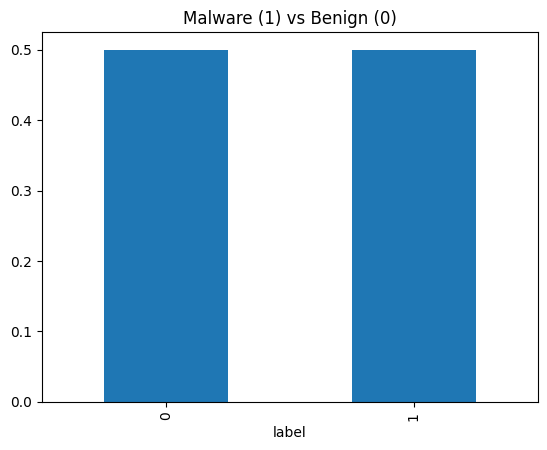

In [4]:
df['label'].value_counts(normalize=True).plot(kind='bar', title='Malware (1) vs Benign (0)')

Loaded 20,000 labelled samples. Columns: ['md5', 'sha1', 'sha256', 'tlsh', 'first_submission_date', 'last_analysis_date', 'detection_ratio', 'label', 'file_type', 'family', 'family_confidence', 'behavior', 'file_property', 'packer', 'exploit', 'group', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories', 'richheader', 'authenticode', 'pefilewarnings', 'week_id', 'caps', 'ttps', 'mbc']

Feature matrix shape: (20000, 63)
Number of features  : 62


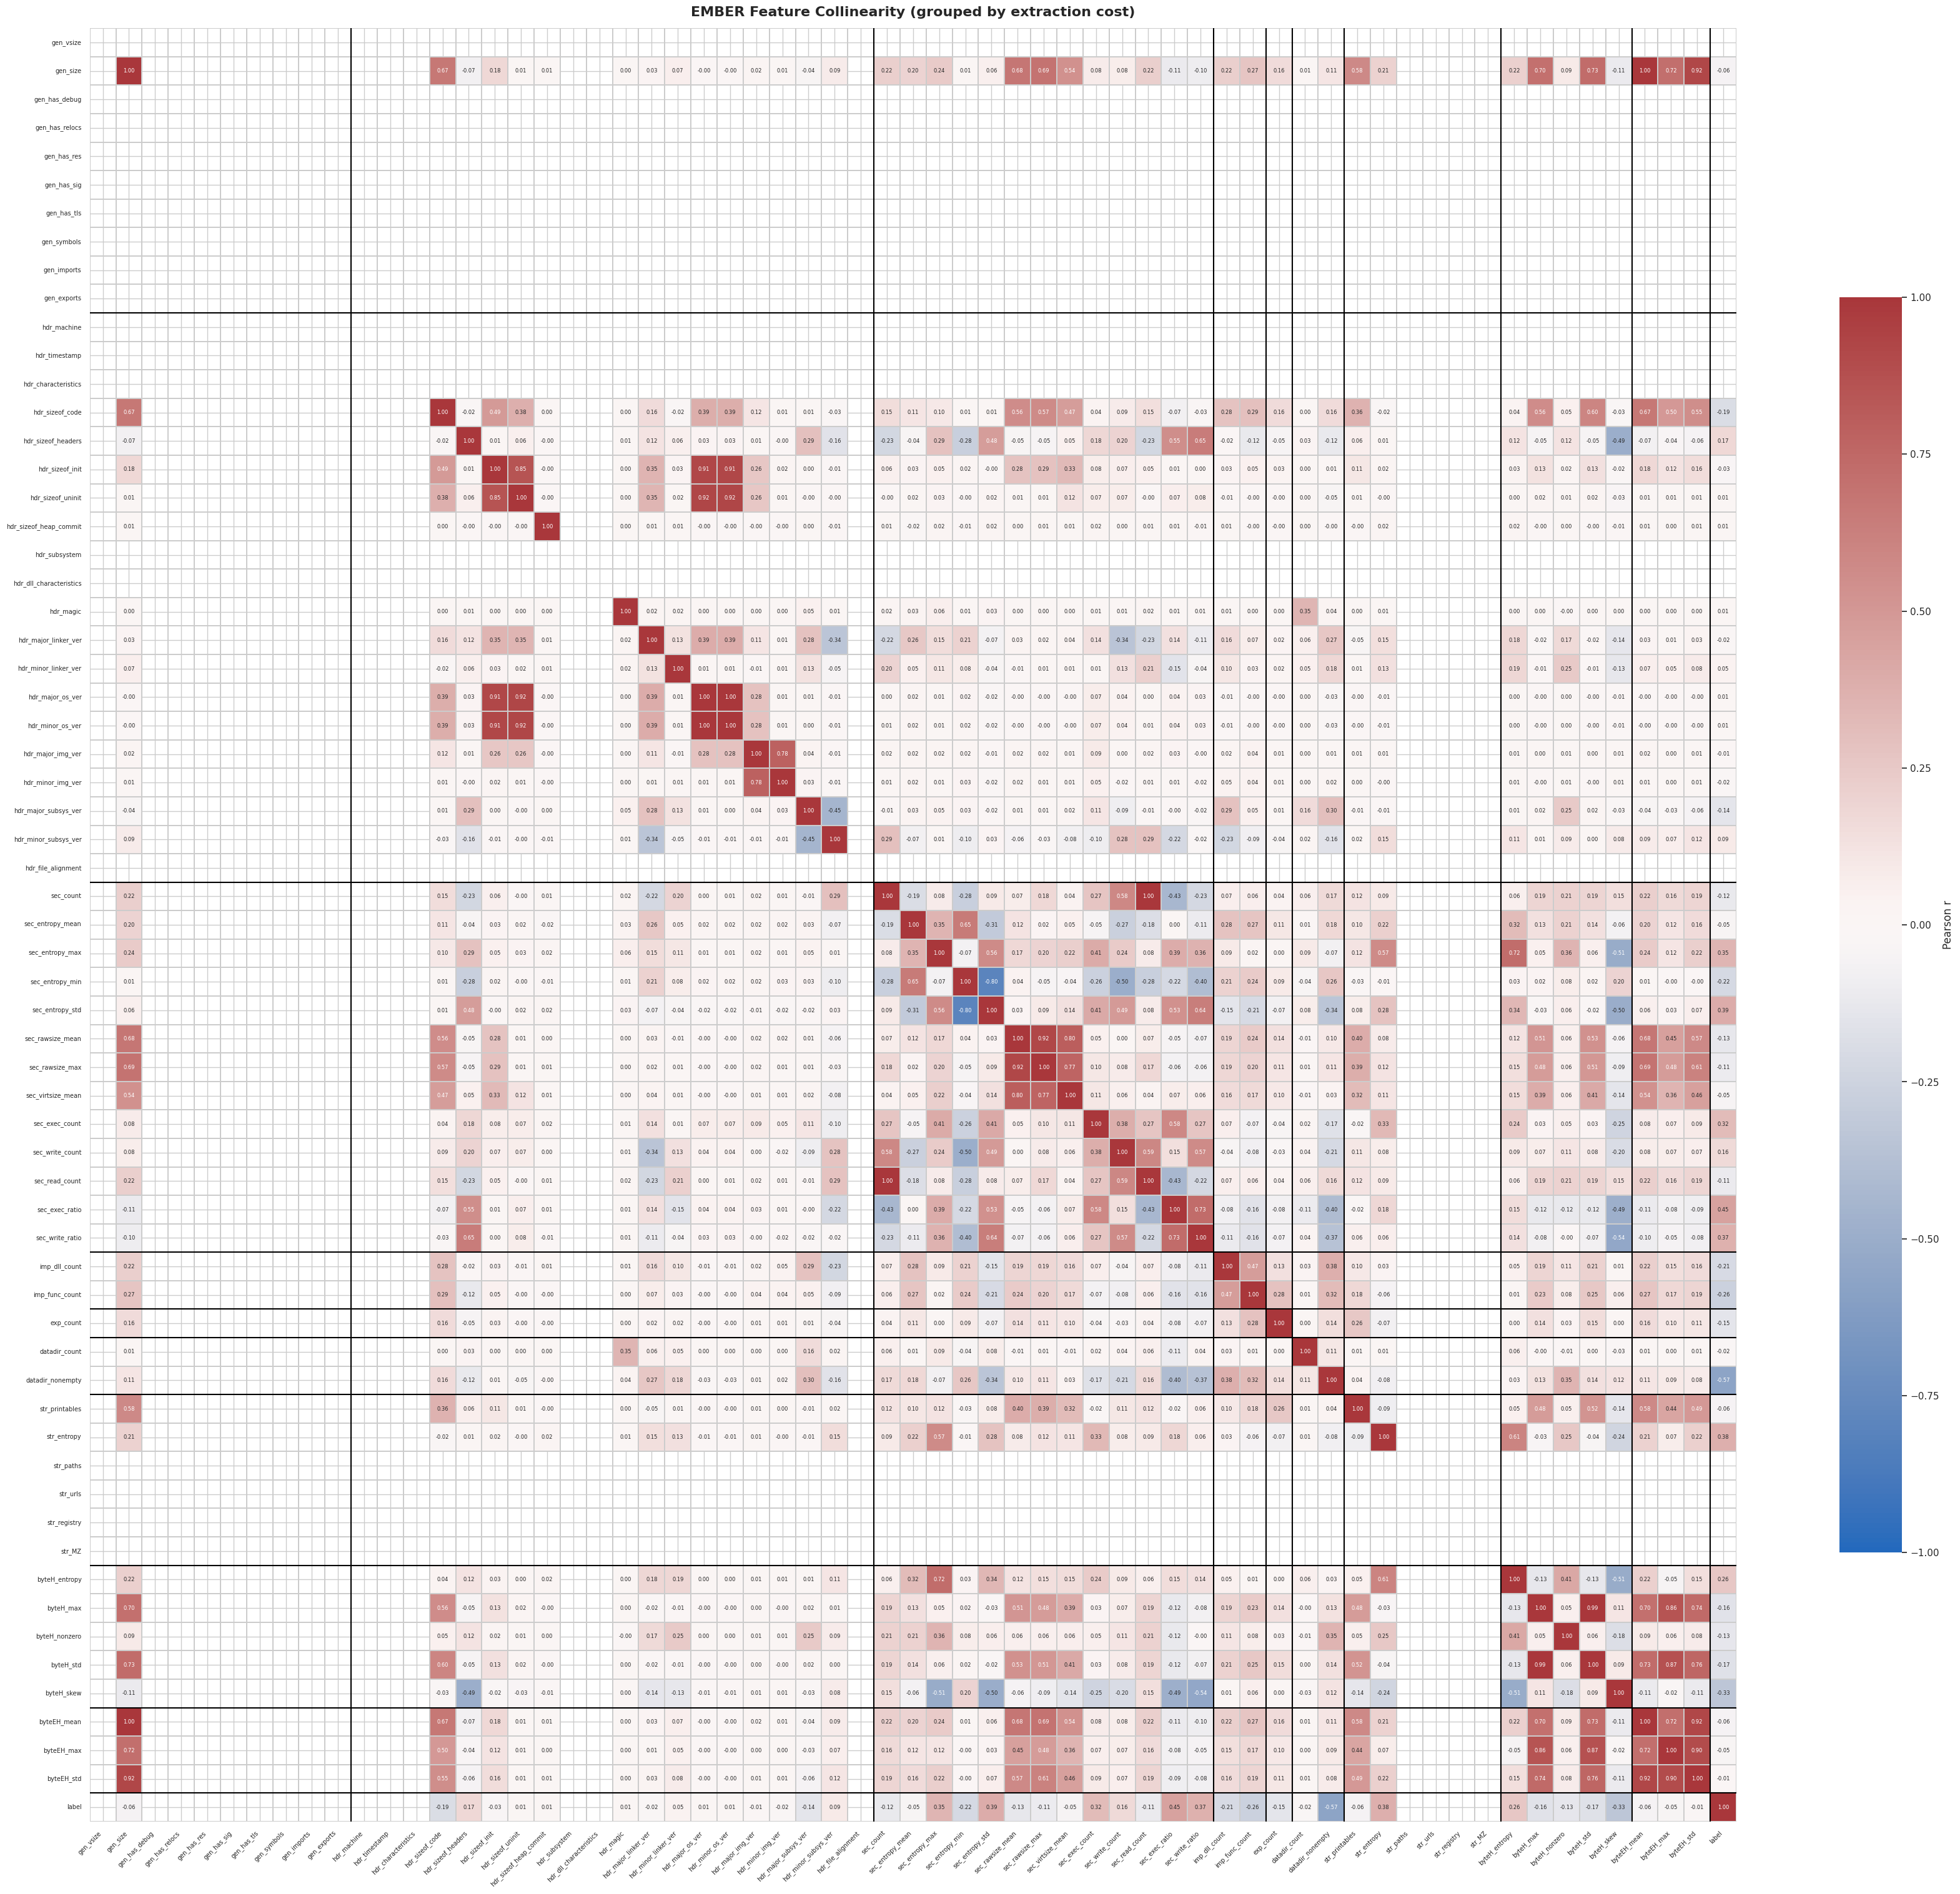

Saved → ember_collinearity_heatmap.png


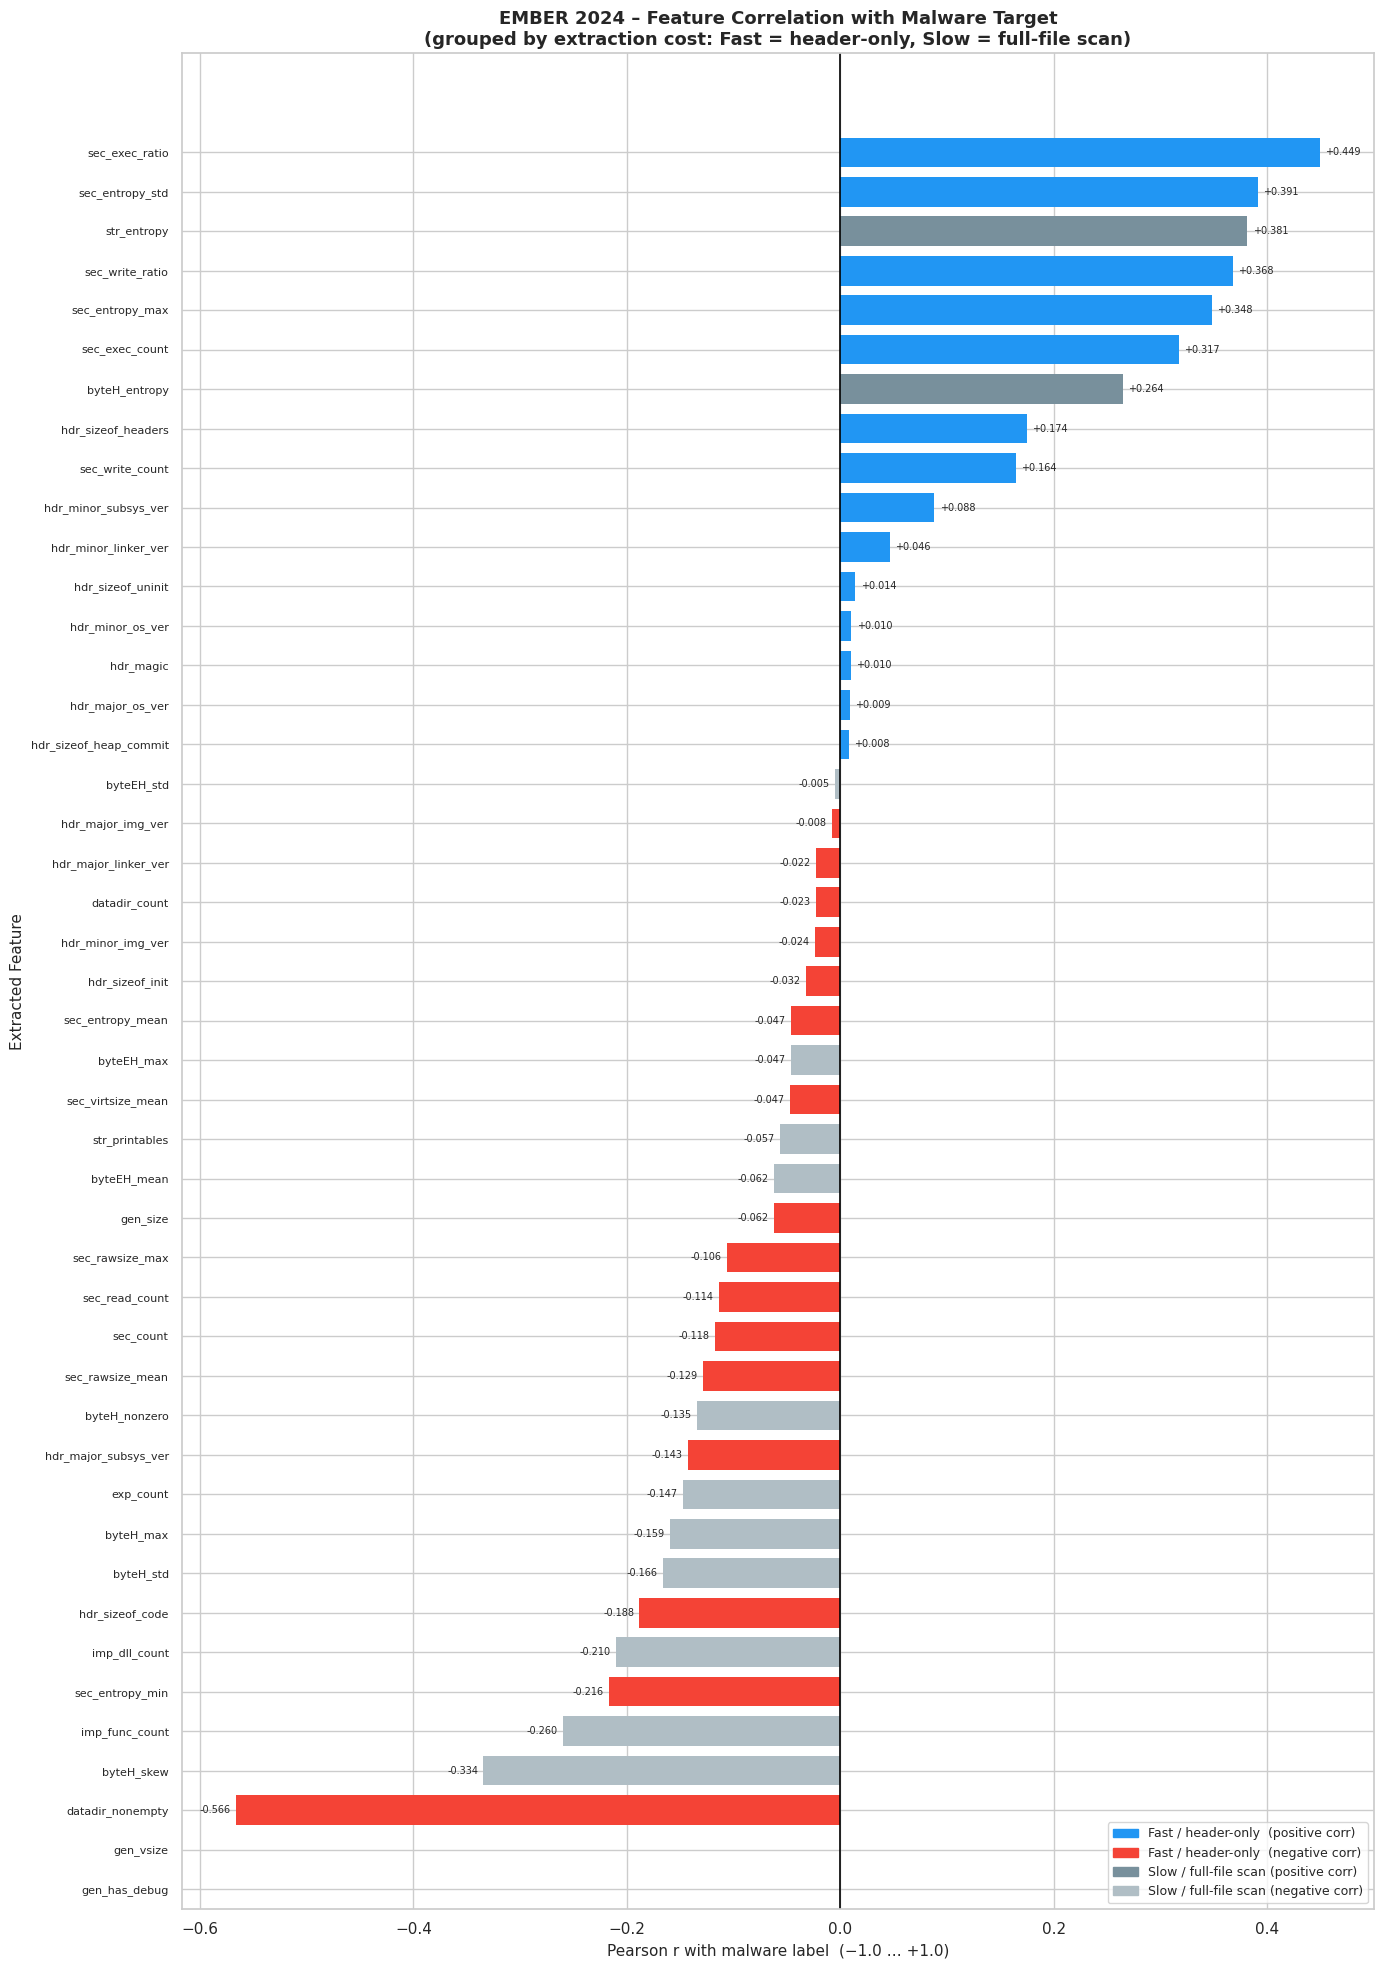

Saved → ember_target_correlation.png

── Top 15 features correlated with malware ──
sec_exec_ratio          0.449045
sec_entropy_std         0.390976
str_entropy             0.381298
sec_write_ratio         0.367623
sec_entropy_max         0.347882
sec_exec_count          0.317040
byteH_entropy           0.264351
hdr_sizeof_headers      0.174444
sec_write_count         0.164106
hdr_minor_subsys_ver    0.088019
hdr_minor_linker_ver    0.046310
hdr_sizeof_uninit       0.013872
hdr_minor_os_ver        0.010192
hdr_magic               0.010001
hdr_major_os_ver        0.008785

── Top 15 features negatively correlated ──
datadir_nonempty       -0.566088
byteH_skew             -0.334391
imp_func_count         -0.259568
sec_entropy_min        -0.216397
imp_dll_count          -0.210422
hdr_sizeof_code        -0.188213
byteH_std              -0.166407
byteH_max              -0.159386
exp_count              -0.147039
hdr_major_subsys_ver   -0.143086
byteH_nonzero          -0.134750
sec_rawsize_m

In [15]:
# Drop rows with unknown labels (-1 in EMBER)
if 'label' in df.columns:
    df = df[df['label'] != -1].copy()

print(f"Loaded {len(df):,} labelled samples. Columns: {df.columns.tolist()}")


# 1. FEATURE EXTRACTION HELPERS
def safe_get(d, *keys, default=0):
    """Safely traverse nested dicts."""
    for k in keys:
        if not isinstance(d, dict):
            return default
        d = d.get(k, default)
    return d if d is not None else default


# ── 1a. General ──────────────────────────────────────────────────────────────
df['gen_vsize']       = df['general'].apply(lambda x: safe_get(x, 'vsize'))
df['gen_size']        = df['general'].apply(lambda x: safe_get(x, 'size'))
df['gen_has_debug']   = df['general'].apply(lambda x: safe_get(x, 'has_debug'))
df['gen_has_relocs']  = df['general'].apply(lambda x: safe_get(x, 'has_relocations'))
df['gen_has_res']     = df['general'].apply(lambda x: safe_get(x, 'has_resources'))
df['gen_has_sig']     = df['general'].apply(lambda x: safe_get(x, 'has_signature'))
df['gen_has_tls']     = df['general'].apply(lambda x: safe_get(x, 'has_tls'))
df['gen_symbols']     = df['general'].apply(lambda x: safe_get(x, 'symbols'))
df['gen_imports']     = df['general'].apply(lambda x: safe_get(x, 'imports'))
df['gen_exports']     = df['general'].apply(lambda x: safe_get(x, 'exports'))

# ── 1b. Header – file header ─────────────────────────────────────────────────
df['hdr_machine']           = df['header'].apply(lambda x: safe_get(x, 'file', 'machine'))
df['hdr_timestamp']         = df['header'].apply(lambda x: safe_get(x, 'file', 'timestamp'))
df['hdr_characteristics']   = df['header'].apply(lambda x: safe_get(x, 'file', 'characteristics'))
# Header – optional header
df['hdr_sizeof_code']       = df['header'].apply(lambda x: safe_get(x, 'optional', 'sizeof_code'))
df['hdr_sizeof_headers']    = df['header'].apply(lambda x: safe_get(x, 'optional', 'sizeof_headers'))
df['hdr_sizeof_init']       = df['header'].apply(lambda x: safe_get(x, 'optional', 'sizeof_initialized_data'))
df['hdr_sizeof_uninit']     = df['header'].apply(lambda x: safe_get(x, 'optional', 'sizeof_uninitialized_data'))
df['hdr_sizeof_heap_commit']= df['header'].apply(lambda x: safe_get(x, 'optional', 'sizeof_heap_commit'))
df['hdr_subsystem']         = df['header'].apply(lambda x: safe_get(x, 'optional', 'subsystem'))
df['hdr_dll_characteristics']= df['header'].apply(lambda x: safe_get(x, 'optional', 'dll_characteristics'))
df['hdr_magic']             = df['header'].apply(lambda x: safe_get(x, 'optional', 'magic'))
df['hdr_major_linker_ver']  = df['header'].apply(lambda x: safe_get(x, 'optional', 'major_linker_version'))
df['hdr_minor_linker_ver']  = df['header'].apply(lambda x: safe_get(x, 'optional', 'minor_linker_version'))
df['hdr_major_os_ver']      = df['header'].apply(lambda x: safe_get(x, 'optional', 'major_operating_system_version'))
df['hdr_minor_os_ver']      = df['header'].apply(lambda x: safe_get(x, 'optional', 'minor_operating_system_version'))
df['hdr_major_img_ver']     = df['header'].apply(lambda x: safe_get(x, 'optional', 'major_image_version'))
df['hdr_minor_img_ver']     = df['header'].apply(lambda x: safe_get(x, 'optional', 'minor_image_version'))
df['hdr_major_subsys_ver']  = df['header'].apply(lambda x: safe_get(x, 'optional', 'major_subsystem_version'))
df['hdr_minor_subsys_ver']  = df['header'].apply(lambda x: safe_get(x, 'optional', 'minor_subsystem_version'))
df['hdr_file_alignment']    = df['header'].apply(lambda x: safe_get(x, 'optional', 'file_alignment'))

# ── 1c. Sections ─────────────────────────────────────────────────────────────
def extract_section_features(sec):
    """Aggregate section-level stats into scalar features."""
    if not isinstance(sec, dict):
        return {}
    sections = sec.get('sections', [])
    n = len(sections)
    if n == 0:
        return {'sec_count': 0}

    entropies   = [s.get('entropy', 0)   for s in sections]
    raw_sizes   = [s.get('size', 0)      for s in sections]
    virt_sizes  = [s.get('vsize', 0)     for s in sections]

    props = [s.get('props', []) for s in sections]
    exec_count  = sum(1 for p in props if 'MEM_EXECUTE' in p)
    write_count = sum(1 for p in props if 'MEM_WRITE' in p)
    read_count  = sum(1 for p in props if 'MEM_READ' in p)

    return {
        'sec_count':        n,
        'sec_entropy_mean': np.mean(entropies),
        'sec_entropy_max':  np.max(entropies),
        'sec_entropy_min':  np.min(entropies),
        'sec_entropy_std':  np.std(entropies),
        'sec_rawsize_mean': np.mean(raw_sizes),
        'sec_rawsize_max':  np.max(raw_sizes),
        'sec_virtsize_mean':np.mean(virt_sizes),
        'sec_exec_count':   exec_count,
        'sec_write_count':  write_count,
        'sec_read_count':   read_count,
        'sec_exec_ratio':   exec_count / n,
        'sec_write_ratio':  write_count / n,
    }

sec_df = df['section'].apply(extract_section_features).apply(pd.Series).fillna(0)
df = pd.concat([df, sec_df], axis=1)

# ── 1d. Imports ──────────────────────────────────────────────────────────────
def extract_import_features(imp):
    if not isinstance(imp, dict):
        return {'imp_dll_count': 0, 'imp_func_count': 0}
    dll_count  = len(imp)
    func_count = sum(len(v) if isinstance(v, list) else 0 for v in imp.values())
    return {'imp_dll_count': dll_count, 'imp_func_count': func_count}

imp_df = df['imports'].apply(extract_import_features).apply(pd.Series).fillna(0)
df = pd.concat([df, imp_df], axis=1)

# ── 1e. Exports ──────────────────────────────────────────────────────────────
df['exp_count'] = df['exports'].apply(
    lambda x: len(x) if isinstance(x, (list, dict)) else 0
)

# ── 1f. Datadirectories ──────────────────────────────────────────────────────
df['datadir_count'] = df['datadirectories'].apply(
    lambda x: len(x) if isinstance(x, (list, dict)) else 0
)
# Count non-empty (size > 0) data directories
def count_nonempty_datadirs(ddirs):
    if isinstance(ddirs, list):
        return sum(1 for d in ddirs if isinstance(d, dict) and d.get('size', 0) > 0)
    if isinstance(ddirs, dict):
        return sum(1 for d in ddirs.values() if isinstance(d, dict) and d.get('size', 0) > 0)
    return 0

df['datadir_nonempty'] = df['datadirectories'].apply(count_nonempty_datadirs)

# ── 1g. Strings ──────────────────────────────────────────────────────────────
str_fields = ['printables', 'entropy', 'paths', 'urls', 'registry', 'MZ']
for f in str_fields:
    df[f'str_{f}'] = df['strings'].apply(
        lambda x, fld=f: safe_get(x, fld)
    )

# ── 1h. Byte histogram aggregates (256-dim → 5 scalars) ──────────────────────
def hist_stats(h):
    if not isinstance(h, list) or len(h) == 0:
        return {'byteH_entropy': 0, 'byteH_max': 0,
                'byteH_nonzero': 0, 'byteH_std': 0, 'byteH_skew': 0}
    arr  = np.array(h, dtype=float)
    s    = arr.sum()
    p    = arr / s if s > 0 else arr
    ent  = -np.sum(p[p > 0] * np.log2(p[p > 0]))
    std  = np.std(arr)
    mean = np.mean(arr)
    skew = (np.mean((arr - mean) ** 3) / (std ** 3 + 1e-12))
    return {
        'byteH_entropy':  ent,
        'byteH_max':      arr.max(),
        'byteH_nonzero':  int((arr > 0).sum()),
        'byteH_std':      std,
        'byteH_skew':     skew,
    }

if 'histogram' in df.columns:
    hist_df = df['histogram'].apply(hist_stats).apply(pd.Series).fillna(0)
    df = pd.concat([df, hist_df], axis=1)

# ── 1i. Byte-entropy histogram aggregates ────────────────────────────────────
def byteent_stats(h):
    if not isinstance(h, list) or len(h) == 0:
        return {'byteEH_mean': 0, 'byteEH_max': 0, 'byteEH_std': 0}
    arr = np.array(h, dtype=float)
    return {'byteEH_mean': arr.mean(), 'byteEH_max': arr.max(), 'byteEH_std': arr.std()}

if 'byteentropy' in df.columns:
    beh_df = df['byteentropy'].apply(byteent_stats).apply(pd.Series).fillna(0)
    df = pd.concat([df, beh_df], axis=1)



# 2. BUILD FINAL FEATURE MATRIX
FEATURE_COLS = [c for c in df.columns if c.startswith((
    'gen_', 'hdr_', 'sec_', 'imp_', 'exp_', 'datadir_',
    'str_', 'byteH_', 'byteEH_'
))]

all_cols = ['label'] + FEATURE_COLS
feat_df  = df[all_cols].copy()

for col in feat_df.columns:
    feat_df[col] = pd.to_numeric(feat_df[col], errors='coerce').fillna(0)

corr_matrix = feat_df.corr()

print(f"\nFeature matrix shape: {feat_df.shape}")
print(f"Number of features  : {len(FEATURE_COLS)}")



# fast  = header / general fields  (no full file read)
# slow  = strings, imports, exports, byte histograms (full file scan)
FAST_PREFIXES = ('gen_', 'hdr_', 'sec_', 'datadir_')

def cost(col):
    return 'fast' if col.startswith(FAST_PREFIXES) else 'slow'


# ─────────────────────────────────────────────────────────────────────────────
# 4. PLOT 1 – COLLINEARITY HEATMAP
# ─────────────────────────────────────────────────────────────────────────────

# Sort features so related groups are adjacent
GROUP_ORDER = ['gen_', 'hdr_', 'sec_', 'imp_', 'exp_', 'datadir_',
               'str_', 'byteH_', 'byteEH_', 'label']

def group_key(col):
    for i, prefix in enumerate(GROUP_ORDER):
        if col.startswith(prefix):
            return i
    return 99

sorted_cols = sorted(all_cols, key=group_key)
corr_sorted = corr_matrix.loc[sorted_cols, sorted_cols]

n = len(sorted_cols)
fig_size = max(20, n * 0.55)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.88))

mask = np.zeros_like(corr_sorted, dtype=bool)  # show full matrix

sns.heatmap(
    corr_sorted,
    ax=ax,
    mask=mask,
    cmap='vlag',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    linecolor='#cccccc',
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
)

# Draw group separators
prev = None
sep_positions = []
for i, col in enumerate(sorted_cols):
    grp = group_key(col)
    if grp != prev and prev is not None:
        sep_positions.append(i)
    prev = grp

for pos in sep_positions:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

ax.set_title("EMBER Feature Collinearity (grouped by extraction cost)",
             fontsize=16, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)

plt.tight_layout()
plt.savefig("ember_collinearity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ember_collinearity_heatmap.png")


# ─────────────────────────────────────────────────────────────────────────────
# 5. PLOT 2 – TARGET CORRELATION BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

target_corr = corr_matrix['label'].drop('label').sort_values(ascending=False)

COLOR_MAP = {
    ('fast', 'pos'):  '#2196F3',   # blue
    ('fast', 'neg'):  '#F44336',   # red
    ('slow', 'pos'):  '#78909C',   # slate
    ('slow', 'neg'):  '#B0BEC5',   # light slate
}

bar_colors = []
for feat, val in zip(target_corr.index, target_corr.values):
    c = cost(feat)
    direction = 'pos' if val >= 0 else 'neg'
    bar_colors.append(COLOR_MAP[(c, direction)])

fig, ax = plt.subplots(figsize=(14, max(8, len(target_corr) * 0.32)))

bars = ax.barh(target_corr.index, target_corr.values, color=bar_colors,
               edgecolor='none', height=0.75)
ax.invert_yaxis()

# Annotate bar values
for bar, val in zip(bars, target_corr.values):
    pad = 0.005 if val >= 0 else -0.005
    ha  = 'left' if val >= 0 else 'right'
    ax.text(val + pad, bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va='center', ha=ha, fontsize=7)

ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel("Pearson r with malware label  (−1.0 … +1.0)", fontsize=11)
ax.set_ylabel("Extracted Feature", fontsize=11)
ax.set_title("EMBER 2024 – Feature Correlation with Malware Target\n"
             "(grouped by extraction cost: Fast = header-only, Slow = full-file scan)",
             fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

legend_patches = [
    mpatches.Patch(color='#2196F3', label='Fast / header-only  (positive corr)'),
    mpatches.Patch(color='#F44336', label='Fast / header-only  (negative corr)'),
    mpatches.Patch(color='#78909C', label='Slow / full-file scan (positive corr)'),
    mpatches.Patch(color='#B0BEC5', label='Slow / full-file scan (negative corr)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("ember_target_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ember_target_correlation.png")


# 6. QUICK SUMMARY TABLE
print("\n── Top 15 features correlated with malware ──")
print(target_corr.head(15).to_string())
print("\n── Top 15 features negatively correlated ──")

# Keep only numeric values and drop NaNs
negative_corr = (
    target_corr
    .select_dtypes(include=["number"])  # keep numeric only (if DataFrame)
    if hasattr(target_corr, "select_dtypes")
    else target_corr                    # if it's a Series, skip this step
)

negative_corr = negative_corr.dropna()

# Sort to ensure most negative values are at the bottom
negative_corr = negative_corr.sort_values()

# Print bottom 15 (most negative)
print(negative_corr.head(15).to_string())

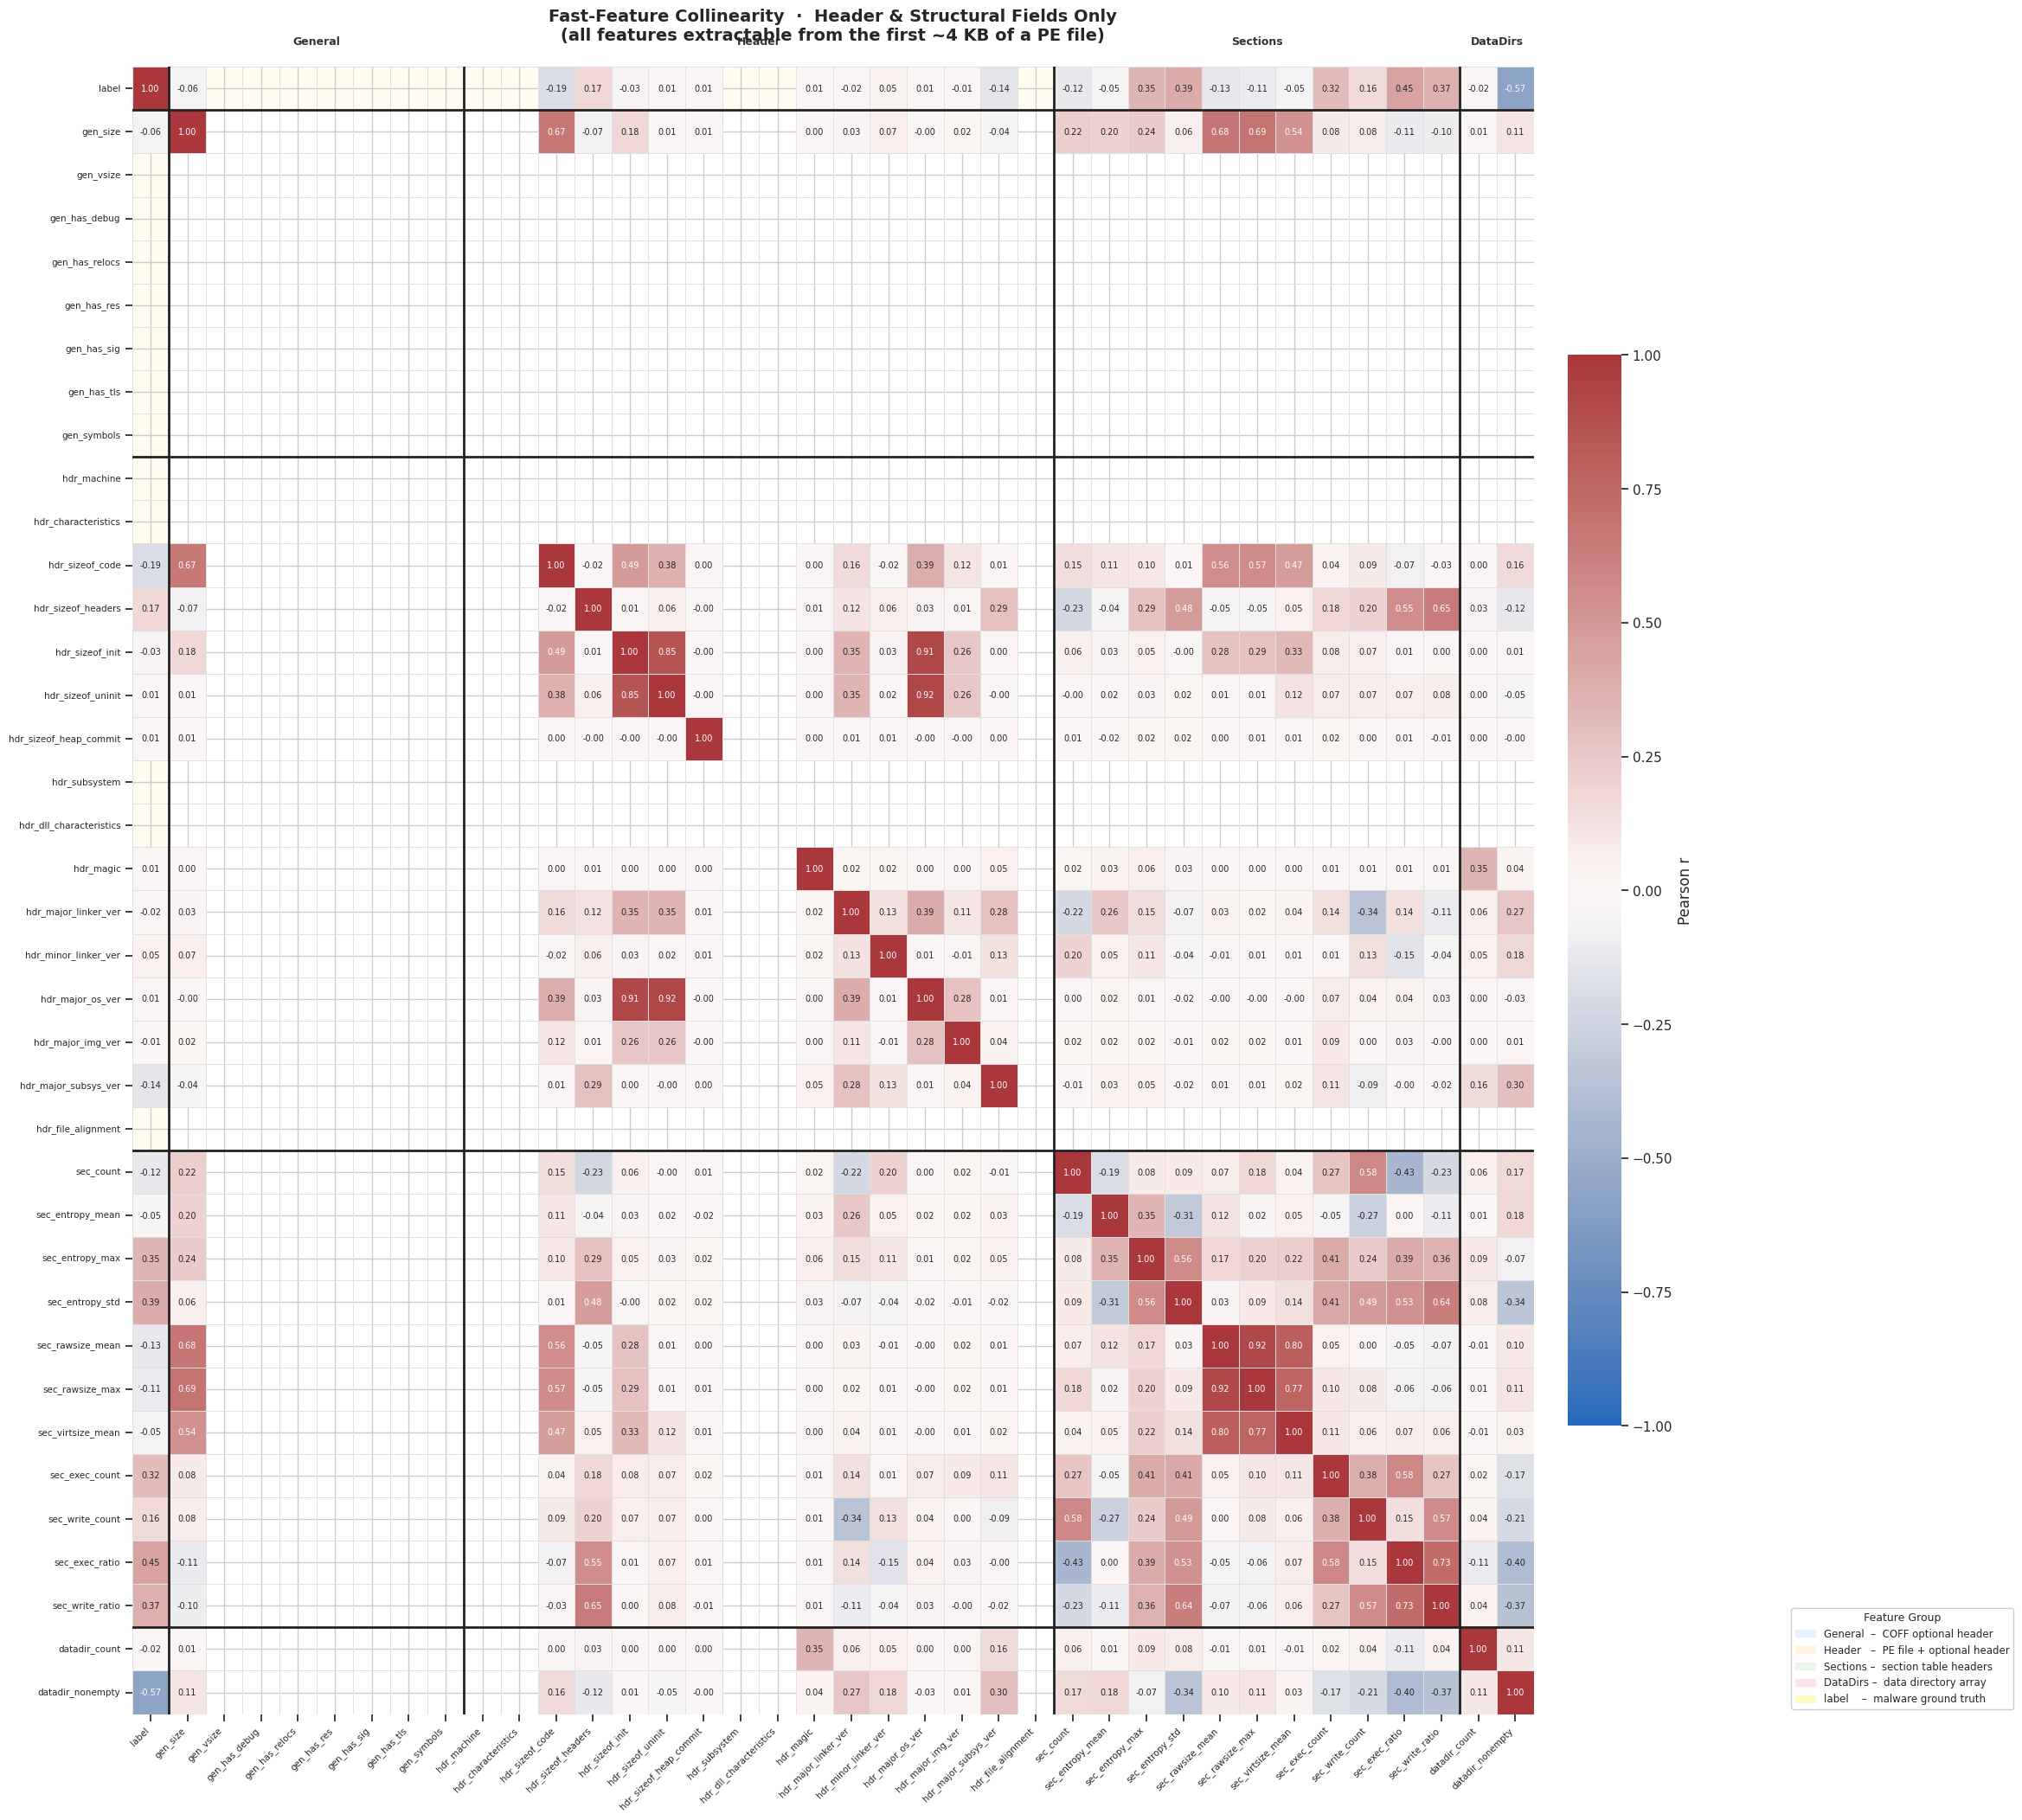

Saved → ember_fast_feature_collinearity.png

── Fast features ranked by |correlation| with malware label ──
  datadir_nonempty                -0.5661   [DataDirs]
  sec_exec_ratio                  +0.4490   [Sections]
  sec_entropy_std                 +0.3910   [Sections]
  sec_write_ratio                 +0.3676   [Sections]
  sec_entropy_max                 +0.3479   [Sections]
  sec_exec_count                  +0.3170   [Sections]
  hdr_sizeof_code                 -0.1882   [Header]
  hdr_sizeof_headers              +0.1744   [Header]
  sec_write_count                 +0.1641   [Sections]
  hdr_major_subsys_ver            -0.1431   [Header]
  sec_rawsize_mean                -0.1290   [Sections]
  sec_count                       -0.1179   [Sections]
  sec_rawsize_max                 -0.1064   [Sections]
  gen_size                        -0.0625   [General]
  sec_virtsize_mean               -0.0474   [Sections]
  sec_entropy_mean                -0.0466   [Sections]
  hdr_minor_linker_

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# FAST-FEATURES COLLINEARITY HEATMAP
# Only features recoverable from the PE header / first ~1-2 MB of file
# ─────────────────────────────────────────────────────────────────────────────
#
#  gen_*        → parsed from the COFF/PE optional header (first ~1KB)
#  hdr_*        → PE file header + optional header fields (first ~1KB)
#  sec_*        → section table sits immediately after the optional header;
#                 ALL section headers are read before any section body
#  datadir_*    → data directory array is part of the optional header
#
# Everything below can be extracted with a single 4KB mmap read on most PEs.
# ─────────────────────────────────────────────────────────────────────────────

FAST_FEATURE_GROUPS = {

    # ── General (from COFF optional header) ──────────────────────────────────
    'General': [
        'gen_size',          # file size on disk
        'gen_vsize',         # virtual size in memory
        'gen_has_debug',     # debug directory present flag
        'gen_has_relocs',    # relocation table present flag
        'gen_has_res',       # resource section present flag
        'gen_has_sig',       # authenticode signature present flag
        'gen_has_tls',       # TLS directory present flag
        'gen_symbols',       # symbol count in COFF symbol table
    ],

    # ── PE File Header + Optional Header ─────────────────────────────────────
    'Header': [
        'hdr_machine',           # target CPU architecture (x86 / x64 / ARM…)
        'hdr_characteristics',   # file characteristic flags (DLL, EXE, …)
        'hdr_sizeof_code',       # total size of all code sections
        'hdr_sizeof_headers',    # combined size of all headers
        'hdr_sizeof_init',       # size of initialised-data sections
        'hdr_sizeof_uninit',     # size of uninitialised-data sections
        'hdr_sizeof_heap_commit',# heap commit size (often abused by packers)
        'hdr_subsystem',         # Windows subsystem (GUI / CUI / …)
        'hdr_dll_characteristics', # ASLR / DEP / CFG flags
        'hdr_magic',             # PE32 vs PE32+ (64-bit)
        'hdr_major_linker_ver',  # linker version (major)
        'hdr_minor_linker_ver',  # linker version (minor)
        'hdr_major_os_ver',      # minimum OS version (major)
        'hdr_major_img_ver',     # image version (major)
        'hdr_major_subsys_ver',  # subsystem version (major)
        'hdr_file_alignment',    # section file-alignment granularity
    ],

    # ── Section Table (headers only – no section bodies needed) ──────────────
    'Sections': [
        'sec_count',          # number of sections
        'sec_entropy_mean',   # mean section entropy (packing indicator)
        'sec_entropy_max',    # max section entropy
        'sec_entropy_std',    # spread in entropy across sections
        'sec_rawsize_mean',   # mean raw-on-disk size per section
        'sec_rawsize_max',    # largest section on disk
        'sec_virtsize_mean',  # mean virtual size per section
        'sec_exec_count',     # number of executable sections
        'sec_write_count',    # number of writable sections
        'sec_exec_ratio',     # fraction of executable sections
        'sec_write_ratio',    # fraction of writable sections
    ],

    # ── Data Directory (array in optional header) ─────────────────────────────
    'DataDirs': [
        'datadir_count',      # total data directory slots
        'datadir_nonempty',   # how many slots have a non-zero size
    ],
}

# Flatten to ordered list, preserving group order
GROUP_ORDER   = list(FAST_FEATURE_GROUPS.keys())
ORDERED_FEATS = ['label'] + [f for g in GROUP_ORDER for f in FAST_FEATURE_GROUPS[g]]

# Keep only columns that actually exist in feat_df
ORDERED_FEATS = [c for c in ORDERED_FEATS if c in feat_df.columns]

fast_corr = feat_df[ORDERED_FEATS].corr()

# ── Group boundary positions ──────────────────────────────────────────────────
def build_separators(ordered_cols):
    """Return the index positions where a new group begins (for gridlines)."""
    col_to_group = {}
    for grp, feats in FAST_FEATURE_GROUPS.items():
        for f in feats:
            col_to_group[f] = grp
    col_to_group['label'] = '__label__'

    seps, midpoints, labels_mid = [], [], []
    prev_grp, start = None, 0
    for i, col in enumerate(ordered_cols):
        grp = col_to_group.get(col, '__other__')
        if grp != prev_grp:
            if prev_grp is not None:
                seps.append(i)
                midpoints.append((start + i) / 2)
                labels_mid.append(prev_grp)
            start = i
            prev_grp = grp
    midpoints.append((start + len(ordered_cols)) / 2)
    labels_mid.append(prev_grp)
    return seps, midpoints, labels_mid

seps, midpoints, group_labels = build_separators(ORDERED_FEATS)

# ── Figure ────────────────────────────────────────────────────────────────────
n        = len(ORDERED_FEATS)
fig_size = max(16, n * 0.62)

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.90))

sns.heatmap(
    fast_corr,
    ax=ax,
    cmap='vlag',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.4,
    linecolor='#e0e0e0',
    cbar_kws={"shrink": 0.65, "label": "Pearson r", "pad": 0.02},
)

# ── Group separator lines ──────────────────────────────────────────────────────
for pos in seps:
    ax.axhline(pos, color='#222222', linewidth=2.0, zorder=5)
    ax.axvline(pos, color='#222222', linewidth=2.0, zorder=5)

# ── Group label banners along the top & left ──────────────────────────────────
GROUP_COLORS = {
    'label':    '#F5F5F5',
    '__label__':'#F5F5F5',
    'General':  '#E3F2FD',
    'Header':   '#FFF3E0',
    'Sections': '#E8F5E9',
    'DataDirs': '#FCE4EC',
}

ax_top  = ax.twiny()
ax_left = ax.twinx()

for spine in ['top', 'bottom', 'left', 'right']:
    ax_top.spines[spine].set_visible(False)
    ax_left.spines[spine].set_visible(False)

ax_top.set_xlim(ax.get_xlim())
ax_left.set_ylim(ax.get_ylim())
ax_top.set_xticks([])
ax_left.set_yticks([])

# Shade columns/rows by group using axvspan / axhspan
col_to_group = {'label': '__label__'}
for grp, feats in FAST_FEATURE_GROUPS.items():
    for f in feats:
        col_to_group[f] = grp

prev_grp, span_start = None, 0
for i, col in enumerate(ORDERED_FEATS):
    grp = col_to_group.get(col, '__other__')
    if grp != prev_grp and prev_grp is not None:
        color = GROUP_COLORS.get(prev_grp, '#FAFAFA')
        # top banner
        ax.annotate(
            '' if prev_grp == '__label__' else prev_grp,
            xy=((span_start + i) / 2 / n, 1.012),
            xycoords='axes fraction',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='#333333',
            xytext=(0, 0), textcoords='offset points',
        )
        span_start = i
    prev_grp = grp
# last group
ax.annotate(
    '' if prev_grp == '__label__' else prev_grp,
    xy=((span_start + n) / 2 / n, 1.012),
    xycoords='axes fraction',
    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333',
)

# ── Highlight the "label" row/column distinctly ───────────────────────────────
label_idx = ORDERED_FEATS.index('label')
ax.add_patch(plt.Rectangle(
    (label_idx, 0), 1, n,
    fill=True, color='#FFF9C4', alpha=0.25, zorder=0, transform=ax.transData
))
ax.add_patch(plt.Rectangle(
    (0, label_idx), n, 1,
    fill=True, color='#FFF9C4', alpha=0.25, zorder=0, transform=ax.transData
))

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7.5)

ax.set_title(
    "Fast-Feature Collinearity  ·  Header & Structural Fields Only\n"
    "(all features extractable from the first ~4 KB of a PE file)",
    fontsize=14, fontweight='bold', pad=22
)

# ── Legend: group colour key ──────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color='#E3F2FD', label='General  –  COFF optional header'),
    mpatches.Patch(color='#FFF3E0', label='Header   –  PE file + optional header'),
    mpatches.Patch(color='#E8F5E9', label='Sections –  section table headers'),
    mpatches.Patch(color='#FCE4EC', label='DataDirs –  data directory array'),
    mpatches.Patch(color='#FFF9C4', label='label    –  malware ground truth'),
]
ax.legend(
    handles=legend_patches,
    loc='lower left',
    bbox_to_anchor=(1.18, 0.0),
    fontsize=8.5,
    title='Feature Group',
    title_fontsize=9,
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig("ember_fast_feature_collinearity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ember_fast_feature_collinearity.png")

# ── Quick insight summary ──────────────────────────────────────────────────────
fast_target = fast_corr['label'].drop('label').sort_values(key=abs, ascending=False)
print("\n── Fast features ranked by |correlation| with malware label ──")
for feat, val in fast_target.items():
    if not (np.isnan(val)):
        grp = col_to_group.get(feat, '?')
        print(f"  {feat:<30s}  {val:+.4f}   [{grp}]")

Coverage at 2.0 MB cutoff:
  All     : 11,924/20,000 (59.6%)
  Malware : 5,432/10,000 (54.3%)
  Benign  : 6,492/10,000 (64.9%)


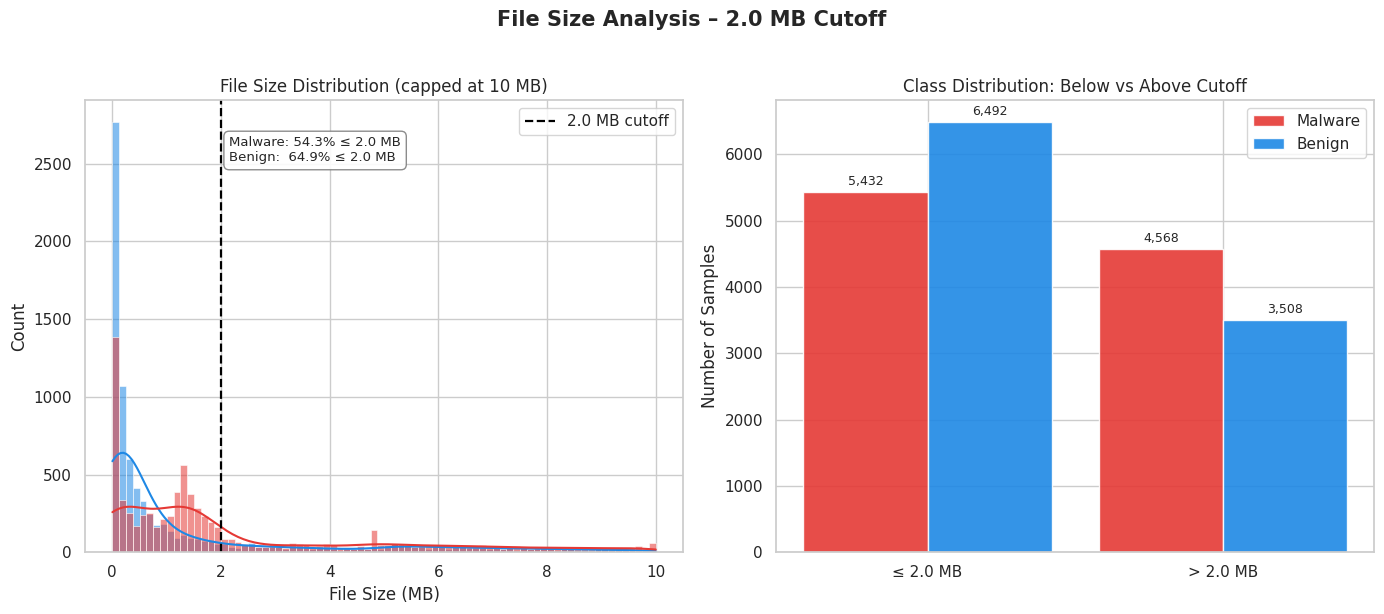

Plot saved as: file_size_cutoff_analysis.png


In [18]:
CUTOFF_MB = 2.0   # change to 2.0 etc. to test different thresholds
PLOT_CAP = 10     # zoom x-axis up to this value (MB)

sns.set_theme(style="whitegrid")
total = len(df)

# Extract file size
df['file_size_bytes'] = df['general'].apply(
    lambda x: x.get('size', 0) if isinstance(x, dict) else 0
)
df['file_size_mb'] = df['file_size_bytes'] / (1024 * 1024)

# Friendly label for plotting
df['label_str'] = df['label'].map({1: 'Malware', 0: 'Benign'})

# Compute coverage stats
mal = df[df['label'] == 1]
ben = df[df['label'] == 0]

def coverage(subset):
    under = (subset['file_size_mb'] <= CUTOFF_MB).sum()
    return under, len(subset), 100 * under / len(subset) if len(subset) else 0

mal_under, mal_total, mal_pct = coverage(mal)
ben_under, ben_total, ben_pct = coverage(ben)
all_under, all_total, all_pct = coverage(df)

print(f"Coverage at {CUTOFF_MB} MB cutoff:")
print(f"  All     : {all_under:,}/{all_total:,} ({all_pct:.1f}%)")
print(f"  Malware : {mal_under:,}/{mal_total:,} ({mal_pct:.1f}%)")
print(f"  Benign  : {ben_under:,}/{ben_total:,} ({ben_pct:.1f}%)")

PALETTE = {'Malware': '#E53935', 'Benign': '#1E88E5'}

plot_df = df[df['file_size_mb'] <= PLOT_CAP].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"File Size Analysis – {CUTOFF_MB} MB Cutoff", 
             fontsize=15, fontweight='bold', y=1.02)

# Left: Histogram + KDE
ax1 = axes[0]
sns.histplot(
    data=plot_df, 
    x='file_size_mb', 
    hue='label_str',
    bins=80, 
    kde=True,
    palette=PALETTE,
    alpha=0.55,
    ax=ax1,
    hue_order=['Malware', 'Benign']
)
ax1.axvline(CUTOFF_MB, color='black', linestyle='--', linewidth=1.6,
            label=f'{CUTOFF_MB} MB cutoff')
ax1.set_title("File Size Distribution (capped at 10 MB)")
ax1.set_xlabel("File Size (MB)")
ax1.set_ylabel("Count")
ax1.legend(title='')

# Annotate coverage percentages
ax1.text(
    CUTOFF_MB + 0.15, ax1.get_ylim()[1] * 0.92,
    f"Malware: {mal_pct:.1f}% ≤ {CUTOFF_MB} MB\n"
    f"Benign:  {ben_pct:.1f}% ≤ {CUTOFF_MB} MB",
    fontsize=9.5, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
              edgecolor='grey', alpha=0.9)
)

# Right: Stacked bar – class balance below/above cutoff
ax2 = axes[1]
below = df[df['file_size_mb'] <= CUTOFF_MB]['label_str'].value_counts()
above = df[df['file_size_mb'] > CUTOFF_MB]['label_str'].value_counts()

categories = [f'≤ {CUTOFF_MB} MB', f'> {CUTOFF_MB} MB']
mal_counts = [below.get('Malware', 0), above.get('Malware', 0)]
ben_counts = [below.get('Benign', 0), above.get('Benign', 0)]

x = np.arange(len(categories))
w = 0.42

ax2.bar(x - w/2, mal_counts, w, label='Malware', color='#E53935', alpha=0.9)
ax2.bar(x + w/2, ben_counts, w, label='Benign',  color='#1E88E5', alpha=0.9)

# Add count labels on bars
for i, cat in enumerate(categories):
    ax2.text(i - w/2, mal_counts[i] + total*0.003, f'{mal_counts[i]:,}', 
             ha='center', va='bottom', fontsize=9)
    ax2.text(i + w/2, ben_counts[i] + total*0.003, f'{ben_counts[i]:,}', 
             ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=11)
ax2.set_title("Class Distribution: Below vs Above Cutoff")
ax2.set_ylabel("Number of Samples")
ax2.legend()

plt.tight_layout()
plt.savefig("file_size_cutoff_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as: file_size_cutoff_analysis.png")

/tmp/ipykernel_55/167121991.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/167121991.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


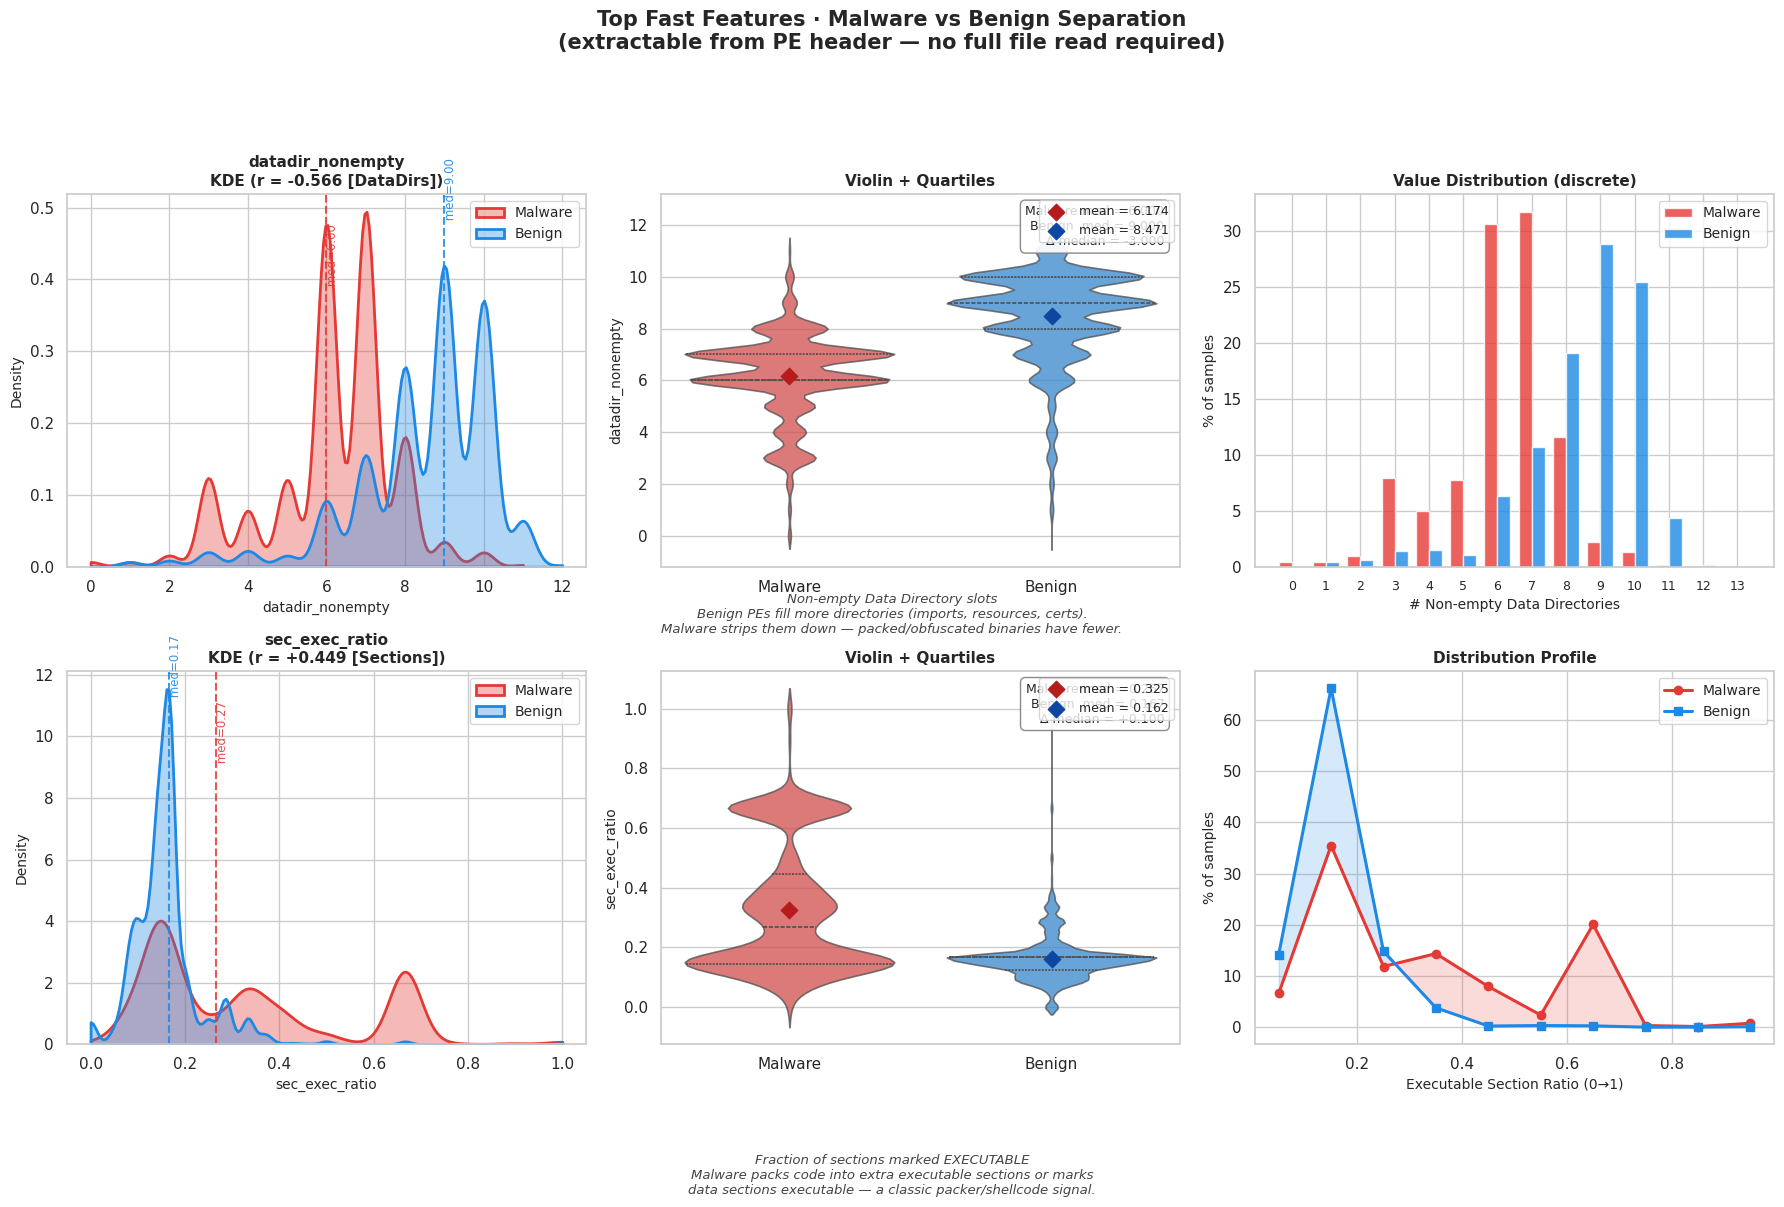

Saved → top2_fast_features_malware_benign.png


In [20]:
# Assuming feat_df is already defined elsewhere with columns including:
# 'datadir_nonempty', 'sec_exec_ratio', 'label' (0=benign, 1=malware)

PALETTE = {1: '#E53935', 0: '#1E88E5'}
LABELS = {1: 'Malware', 0: 'Benign'}

mal = feat_df[feat_df['label'] == 1]
ben = feat_df[feat_df['label'] == 0]

def label_str(df_sub):
    return df_sub['label'].map(LABELS)

# Helper: summary stats string
def stats_box(series, color, label):
    return (f"{label}\n"
            f"median = {series.median():.3f}\n"
            f"mean = {series.mean():.3f}\n"
            f"std = {series.std():.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE LAYOUT – now 2 rows × 3 cols
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Top Fast Features · Malware vs Benign Separation\n"
    "(extractable from PE header — no full file read required)",
    fontsize=15, fontweight='bold', y=1.02
)

FEATURES = [
    ('datadir_nonempty', -0.566, 'DataDirs',
     "Non-empty Data Directory slots\n"
     "Benign PEs fill more directories (imports, resources, certs).\n"
     "Malware strips them down — packed/obfuscated binaries have fewer."),
     
    ('sec_exec_ratio', +0.449, 'Sections',
     "Fraction of sections marked EXECUTABLE\n"
     "Malware packs code into extra executable sections or marks\n"
     "data sections executable — a classic packer/shellcode signal."),
]

for row, (feat, r_val, group, insight) in enumerate(FEATURES):
    mal_vals = mal[feat]
    ben_vals = ben[feat]
    combined = feat_df[[feat, 'label']].copy()
    combined['Class'] = combined['label'].map(LABELS)
    
    # ── Col 0: KDE + rug ─────────────────────────────────────────────────────
    ax0 = axes[row, 0]
    for lbl, vals, color in [(1, mal_vals, '#E53935'), (0, ben_vals, '#1E88E5')]:
        sns.kdeplot(vals, ax=ax0, color=color, fill=True, alpha=0.35,
                    linewidth=2, label=LABELS[lbl], clip=(vals.min(), vals.max()))
        ax0.axvline(vals.median(), color=color, linestyle='--',
                    linewidth=1.5, alpha=0.85)
    ax0.set_title(f"{feat}\nKDE (r = {r_val:+.3f} [{group}])",
                  fontsize=11, fontweight='bold')
    ax0.set_xlabel(feat, fontsize=10)
    ax0.set_ylabel("Density", fontsize=10)
    ax0.legend(fontsize=10)
    
    # Annotate medians
    for vals, color, va in [(mal_vals, '#E53935', 'top'), (ben_vals, '#1E88E5', 'bottom')]:
        ax0.text(vals.median(), ax0.get_ylim()[1] * 0.92,
                 f" med={vals.median():.2f}", color=color,
                 fontsize=8.5, va=va, rotation=90, alpha=0.9)

    # ── Col 1: Violin + embedded box ─────────────────────────────────────────
    ax1 = axes[row, 1]
    sns.violinplot(
        data=combined, x='Class', y=feat,
        palette={'Malware': '#E53935', 'Benign': '#1E88E5'},
        inner='quartile', order=['Malware', 'Benign'],
        linewidth=1.2, ax=ax1, alpha=0.75
    )
    
    # Overlay mean diamonds
    for cls, vals, color in [('Malware', mal_vals, '#B71C1C'),
                             ('Benign', ben_vals, '#0D47A1')]:
        x_pos = ['Malware', 'Benign'].index(cls)
        ax1.scatter(x_pos, vals.mean(), color=color, s=70, zorder=5,
                    marker='D', label=f'mean = {vals.mean():.3f}')
    
    ax1.set_title(f"Violin + Quartiles", fontsize=11, fontweight='bold')
    ax1.set_xlabel("")
    ax1.set_ylabel(feat, fontsize=10)
    ax1.legend(fontsize=9, loc='upper right')
    
    # Stats annotation box
    stats_text = (f"Malware med = {mal_vals.median():.3f}\n"
                  f"Benign  med = {ben_vals.median():.3f}\n"
                  f"Δ median = {mal_vals.median() - ben_vals.median():+.3f}")
    ax1.text(0.97, 0.97, stats_text,
             transform=ax1.transAxes, fontsize=9, va='top', ha='right',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='grey', alpha=0.92))

    # ── Col 2: Feature-specific insight ──────────────────────────────────────
    ax2 = axes[row, 2]
    
    if feat == 'datadir_nonempty':
        max_val = int(combined[feat].max())
        bins = list(range(max_val + 2))
        mal_hist = mal_vals.value_counts(normalize=True).reindex(bins, fill_value=0)
        ben_hist = ben_vals.value_counts(normalize=True).reindex(bins, fill_value=0)
        x = np.arange(len(bins))
        w = 0.38
        ax2.bar(x - w/2, mal_hist.values * 100, w,
                color='#E53935', alpha=0.8, label='Malware')
        ax2.bar(x + w/2, ben_hist.values * 100, w,
                color='#1E88E5', alpha=0.8, label='Benign')
        ax2.set_xticks(x)
        ax2.set_xticklabels(bins, fontsize=9)
        ax2.set_xlabel("# Non-empty Data Directories", fontsize=10)
        ax2.set_ylabel("% of samples", fontsize=10)
        ax2.set_title("Value Distribution (discrete)", fontsize=11, fontweight='bold')
        ax2.legend(fontsize=10)
        
    elif feat == 'sec_exec_ratio':
        buckets = np.linspace(0, 1, 11)
        mal_h, _ = np.histogram(mal_vals.clip(0, 1), bins=buckets, density=False)
        ben_h, _ = np.histogram(ben_vals.clip(0, 1), bins=buckets, density=False)
        mal_pct = mal_h / mal_h.sum() * 100 if mal_h.sum() > 0 else mal_h
        ben_pct = ben_h / ben_h.sum() * 100 if ben_h.sum() > 0 else ben_h
        centres = (buckets[:-1] + buckets[1:]) / 2
        ax2.plot(centres, mal_pct, 'o-', color='#E53935', linewidth=2.2,
                 markersize=6, label='Malware')
        ax2.plot(centres, ben_pct, 's-', color='#1E88E5', linewidth=2.2,
                 markersize=6, label='Benign')
        ax2.fill_between(centres, mal_pct, ben_pct,
                         where=(mal_pct >= ben_pct),
                         interpolate=True, alpha=0.18, color='#E53935')
        ax2.fill_between(centres, mal_pct, ben_pct,
                         where=(mal_pct < ben_pct),
                         interpolate=True, alpha=0.18, color='#1E88E5')
        ax2.set_xlabel("Executable Section Ratio (0→1)", fontsize=10)
        ax2.set_ylabel("% of samples", fontsize=10)
        ax2.set_title("Distribution Profile", fontsize=11, fontweight='bold')
        ax2.legend(fontsize=10)

    # Insight text below each row
    fig.text(0.5, (1 - row) / 2 - 0.02 + 0.01 * (1-row),
             insight, ha='center', va='top', fontsize=9.5,
             style='italic', color='#444444',
             transform=fig.transFigure)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig("top2_fast_features_malware_benign.png", dpi=160, bbox_inches='tight')
plt.show()
print("Saved → top2_fast_features_malware_benign.png")